In [1]:
#Import libraries and specify paths

import pandas as pd
import numpy  as np
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier
from sklearn.metrics  import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report
import warnings
warnings.filterwarnings('ignore')

print("Librarties imported")

train_csv=r"C:\Users\NARASIMHA N\OneDrive\Desktop\Kitsune Feature Extraction\Dataset Preprocessing\CICIoT2023 Dataset\Test and Train Sets\CICIoT2023_train.csv"
test_csv=r"C:\Users\NARASIMHA N\OneDrive\Desktop\Kitsune Feature Extraction\Dataset Preprocessing\CICIoT2023 Dataset\Test and Train Sets\CICIoT2023_test.csv"

print("Paths are set")

Librarties imported
Paths are set


In [2]:
#load train and test data

train_df=pd.read_csv(train_csv)
test_df=pd.read_csv(test_csv)

print(f"Train CSV: {train_df.shape}")
print(f"Test CSV: {test_df.shape}")

print(f"\nTrain label Distribution: {train_df['label'].value_counts().to_dict()}")
print(f"\nTest label Distribution: {test_df['label'].value_counts().to_dict()}")

Train CSV: (32000, 104)
Test CSV: (8000, 104)

Train label Distribution: {0: 16000, 1: 16000}

Test label Distribution: {1: 4000, 0: 4000}


In [3]:
#Separate features and label

feature_columns=[feature for feature in train_df.columns if feature!='label']

X_train=train_df[feature_columns]
y_train=train_df['label']

X_test=test_df[feature_columns]
y_test=test_df['label']

print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train distribution: {y_train.value_counts().to_dict()}")
print(f"y_test distribution: {y_test.value_counts().to_dict()}")

X_train shape: (32000, 103)
X_test shape: (8000, 103)
y_train distribution: {0: 16000, 1: 16000}
y_test distribution: {1: 4000, 0: 4000}


In [4]:
# Definition of all models

models = {
    'Decision Tree': DecisionTreeClassifier(random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42),
    'KNN': KNeighborsClassifier(n_neighbors=5),
    'SVM': SVC(kernel='rbf', random_state=42),
    'Logistic Regression': LogisticRegression(random_state=42, max_iter=1000),
    'XGBoost': XGBClassifier(random_state=42, eval_metric='logloss')
}

print("Models Defined:")
for i in models:
    print(i)

Models Defined:
Decision Tree
Random Forest
KNN
SVM
Logistic Regression
XGBoost


In [5]:
from sklearn.model_selection import StratifiedKFold, cross_val_score

skf=StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

cross_validation_results=[]

print("Running 5-fold Cross-validation on training set....")

for model_name, model in models.items():
    print(f"Cross Validating {model_name}....")

    cross_validadtion_scores=cross_val_score(model, X_train, y_train, cv=skf, scoring="f1")

    cross_validation_results.append({
        "Model": model_name,
        "CV Mean F1": round(cross_validadtion_scores.mean(),4),
        "CV Std F1": round(cross_validadtion_scores.std(),4),
        "CV Min F1": round(cross_validadtion_scores.min(),4),
        "CV Max F1": round(cross_validadtion_scores.max(),4)
    })

    print(f"Fold Scores: {[round(s,4) for s in cross_validadtion_scores]}")
    print(f"Mean F1: {cross_validadtion_scores.mean()}")
    print(f"\nStd F1: {cross_validadtion_scores.std()}")

cross_validation_results_df=pd.DataFrame(cross_validation_results)
cross_validation_results_df=cross_validation_results_df.sort_values('CV Mean F1', ascending =False).reset_index(drop=True)
print("Cross Validation Results:\n")
print(cross_validation_results_df.to_string(index=False))

Running 5-fold Cross-validation on training set....
Cross Validating Decision Tree....
Fold Scores: [np.float64(0.9825), np.float64(0.9848), np.float64(0.9851), np.float64(0.9834), np.float64(0.9829)]
Mean F1: 0.9837531154366467

Std F1: 0.001047233282588266
Cross Validating Random Forest....
Fold Scores: [np.float64(0.9852), np.float64(0.9869), np.float64(0.9874), np.float64(0.9855), np.float64(0.9863)]
Mean F1: 0.9862749235729262

Std F1: 0.0008379174399847061
Cross Validating KNN....
Fold Scores: [np.float64(0.978), np.float64(0.9824), np.float64(0.9819), np.float64(0.9791), np.float64(0.978)]
Mean F1: 0.9798710972383757

Std F1: 0.0019019772703113144
Cross Validating SVM....
Fold Scores: [np.float64(0.9674), np.float64(0.9702), np.float64(0.9731), np.float64(0.9691), np.float64(0.9671)]
Mean F1: 0.9693822359058641

Std F1: 0.002163193785240415
Cross Validating Logistic Regression....
Fold Scores: [np.float64(0.9672), np.float64(0.9703), np.float64(0.9724), np.float64(0.9693), np.fl

In [6]:
#Train and evaluate all models
import time
results=[]

for model_name, model in models.items():
    print(f"Training {model_name}....")

    #train the model on train data
    start_time=time.time()
    model.fit(X_train, y_train)
    end_time=time.time()
    training_time=end_time-start_time

    #predict on test data
    start_time=time.time()
    y_pred=model.predict(X_test)
    end_time=time.time()
    testing_time=end_time-start_time
    
    #metrics calculation
    accuracy=accuracy_score(y_test, y_pred)
    precision=precision_score(y_test, y_pred)
    recall=recall_score(y_test, y_pred)
    f1=f1_score(y_test, y_pred)

    #Storing results
    results.append({
         'Model': model_name,
         'Accuracy': round(accuracy,4),
         'Precision': round(precision,4),
         'Recall': round(recall,4),
         'F1-Score': round(f1,4),
         'Training Time (S)': training_time,
         'Testing Time (S)': testing_time
     })
    print(f"Model Name: {model_name}")
    print(f"Accuracy {accuracy}")
    print(f"Precision: {precision}")
    print(f"Recall: {recall}")
    print(f"F1-Score: {f1}")
    print(f"Training Time: {training_time} seconds")
    print(f"Testing Time: {testing_time} seconds")
     

print("\n All models are trained and evaluated")       
    

Training Decision Tree....
Model Name: Decision Tree
Accuracy 0.98325
Precision: 0.9854344550477148
Recall: 0.981
F1-Score: 0.9832122275119017
Training Time: 4.169919729232788 seconds
Testing Time: 0.019621610641479492 seconds
Training Random Forest....
Model Name: Random Forest
Accuracy 0.98675
Precision: 0.9919151086407276
Recall: 0.9815
F1-Score: 0.9866800703694396
Training Time: 32.929630517959595 seconds
Testing Time: 0.18923592567443848 seconds
Training KNN....
Model Name: KNN
Accuracy 0.980375
Precision: 0.9843710612553567
Recall: 0.97625
F1-Score: 0.9802937115601857
Training Time: 0.0706932544708252 seconds
Testing Time: 2.9756345748901367 seconds
Training SVM....
Model Name: SVM
Accuracy 0.974875
Precision: 0.9984256100760955
Recall: 0.95125
F1-Score: 0.9742670592753808
Training Time: 36.52947759628296 seconds
Testing Time: 7.432129859924316 seconds
Training Logistic Regression....
Model Name: Logistic Regression
Accuracy 0.97525
Precision: 0.9976439790575916
Recall: 0.95275
F

In [7]:
results_df=pd.DataFrame(results)

results_df=results_df.sort_values('F1-Score', ascending=False).reset_index(drop=True)

print("CICIOT2023 Model Comparision:")
print(results_df.to_string(index=False))

CICIOT2023 Model Comparision:
              Model  Accuracy  Precision  Recall  F1-Score  Training Time (S)  Testing Time (S)
            XGBoost    0.9886     0.9902  0.9870    0.9886           5.556813          0.037663
      Random Forest    0.9868     0.9919  0.9815    0.9867          32.929631          0.189236
      Decision Tree    0.9832     0.9854  0.9810    0.9832           4.169920          0.019622
                KNN    0.9804     0.9844  0.9762    0.9803           0.070693          2.975635
Logistic Regression    0.9752     0.9976  0.9527    0.9747           3.235024          0.015249
                SVM    0.9749     0.9984  0.9513    0.9743          36.529478          7.432130


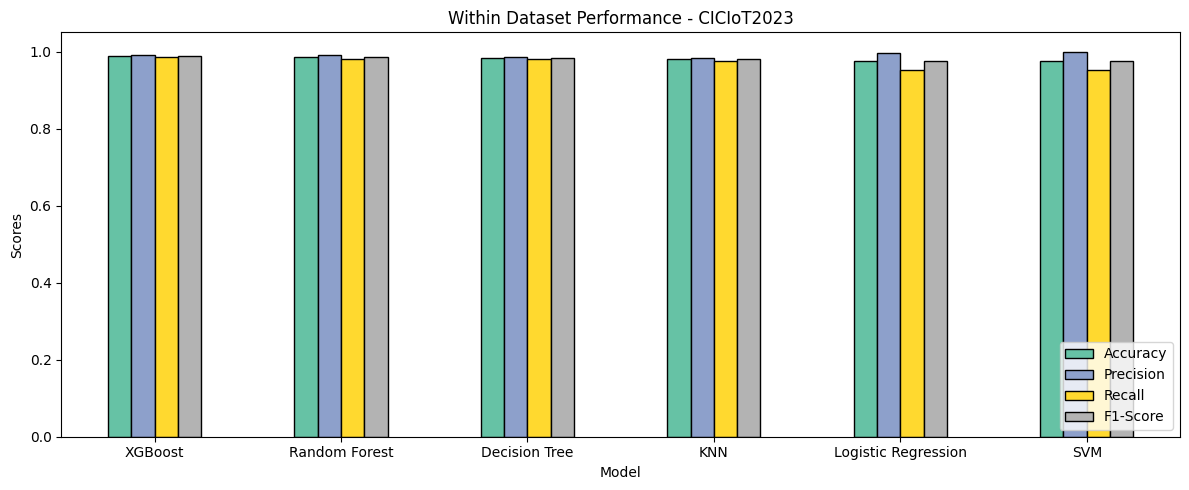

In [8]:
import matplotlib.pyplot as plt

plot_df = results_df.set_index("Model")[["Accuracy", "Precision", "Recall", "F1-Score"]].copy()
plot_df = plot_df.apply(pd.to_numeric, errors="coerce")

plot_df.plot(
    kind="bar",
    figsize=(12, 5),
    ylim=(0, 1.05),
    colormap="Set2",
    edgecolor="black"
)

plt.title("Within Dataset Performance - CICIoT2023")
plt.xlabel("Model")
plt.ylabel("Scores")
plt.xticks(rotation=0)
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()

In [27]:
# Feature Importance

rf = models['Random Forest']
xgb = models['XGBoost']

rf_importance= pd.DataFrame({
    'Feature': feature_columns,
    'Importance': rf.feature_importances_
}).sort_values('Importance', ascending=False).reset_index(drop=True)

xgb_importance = pd.DataFrame({
    'Feature': feature_columns,
    'Importance': xgb.feature_importances_
}).sort_values('Importance', ascending=False).reset_index(drop=True)

print("Top 20 features - Random Forest:")
print(rf_importance.head(20).to_string(index=False))

print("\nTop 20 features - XGBoost:")
print(xgb_importance.head(20).to_string(index=False))

common_top20_features = set(xgb_importance.head(20)['Feature']) & set(rf_importance.head(20)['Feature'])
for feature in common_top20_features:
    print(feature)

Top 20 features - Random Forest:
                Feature  Importance
        HH_jit_0.1_mean    0.089519
   HH_0.1_magnitude_0_1    0.088513
 HpHp_0.1_magnitude_0_1    0.084475
HpHp_0.01_magnitude_0_1    0.080705
   HpHp_3_magnitude_0_1    0.069145
  HH_0.01_magnitude_0_1    0.058728
   HpHp_1_magnitude_0_1    0.058017
     HH_3_magnitude_0_1    0.051611
        HpHp_1_weight_0    0.032621
     HH_1_magnitude_0_1    0.029376
        HH_jit_0.01_std    0.028720
     HH_5_magnitude_0_1    0.026512
        MI_dir_3_weight    0.023916
       HH_jit_0.01_mean    0.021289
         HH_jit_0.1_std    0.019326
          HH_1_weight_0    0.017921
        HH_jit_1_weight    0.017758
        HH_jit_3_weight    0.015834
          HH_jit_1_mean    0.010849
   HpHp_5_magnitude_0_1    0.010581

Top 20 features - XGBoost:
                Feature  Importance
   HH_0.1_magnitude_0_1    0.420062
HpHp_0.01_magnitude_0_1    0.352205
       HH_0.01_weight_0    0.016953
       HH_jit_0.01_mean    0.015237
   

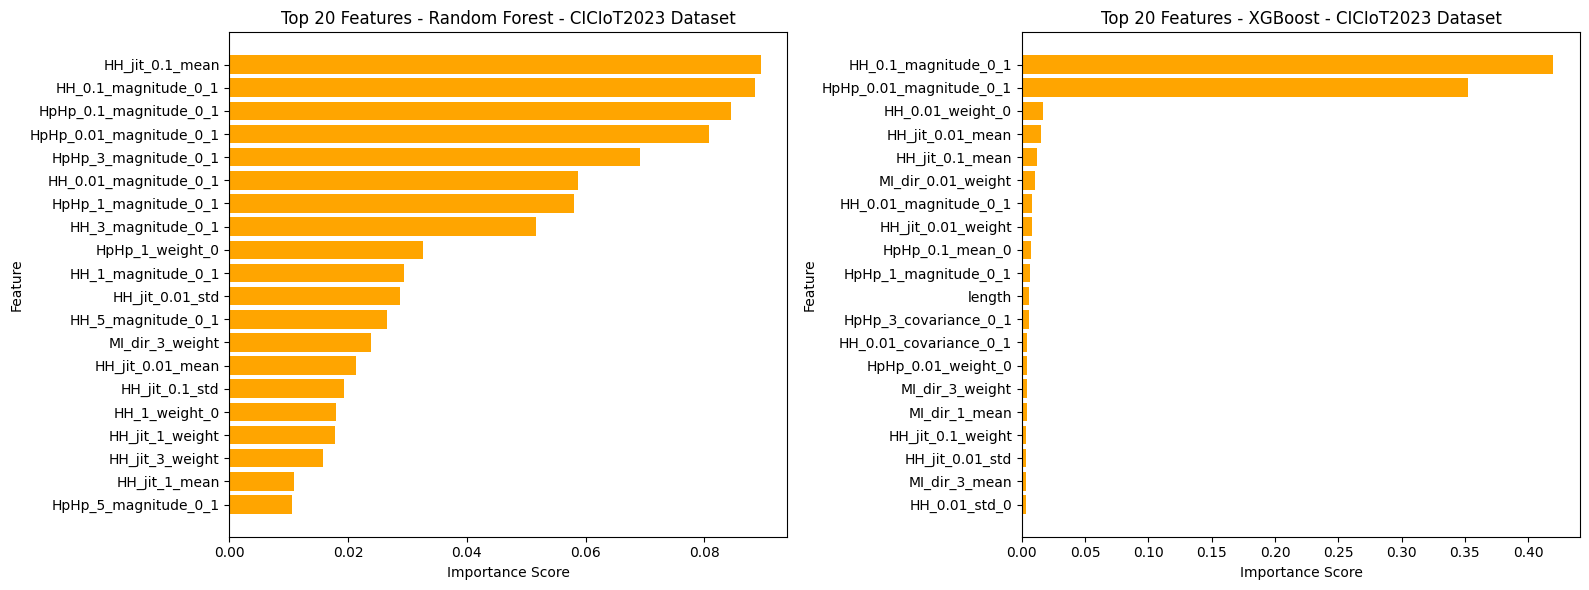

In [23]:
#plot top-20 features

fig, axes=plt.subplots(1,2,figsize=(16,6))

top20_rf=rf_importance.head(20)
axes[0].barh(top20_rf['Feature'][::-1], top20_rf['Importance'][::-1], color='orange')
axes[0].set_title('Top 20 Features - Random Forest - CICIoT2023 Dataset')
axes[0].set_xlabel('Importance Score')
axes[0].set_ylabel('Feature')

top20_xgb=xgb_importance.head(20)
axes[1].barh(top20_xgb['Feature'][::-1], top20_xgb['Importance'][::-1], color='orange')
axes[1].set_title('Top 20 Features - XGBoost - CICIoT2023 Dataset')
axes[1].set_xlabel('Importance Score')
axes[1].set_ylabel('Feature')

plt.tight_layout()
plt.show()